## Comparing Outcome-Based and Learned Reward Representations in Predicting Visual Attention
*Margarita E. Nikolova | Tilburg University* 

This notebook implements the full ML pipeline for my bachelors thesis:
- Three feature sets: outcome-based, RL-based, and combined
- Three models: Logistic Regression, Random Forest, and XGBoost
- 5-fold GroupKFold cross-validation grouped by participant
- AUC-ROC as a primary metric, accuracy as a secondary metric
- Paired t-tests on fold-level AUC scores to compare feature sets
- Impurity-based and permutation feature importance
- Leave-one-subject-out generalization analysis

In [115]:
import sys
print(sys.executable)

c:\Users\margo\anaconda3\python.exe


In [116]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier
from sklearn.model_selection import GroupKFold
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import roc_auc_score, accuracy_score
from sklearn.inspection import permutation_importance
import xgboost
from xgboost import XGBClassifier

import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

### 1. Loading and preparing data:

In [128]:
#original study yielded two independant samples, so we merge them into one for this study:
df1 = pd.read_csv('eyeData_processed_35.csv')
df2 = pd.read_csv('eyeData_processed_64.csv')
df2['subject'] = df2['subject'] + df1['subject'].max()


print("sample 1 subject range:", df1['subject'].min(), "-", df1['subject'].max())
print("sample 2 subject range before offset:", df2['subject'].min(), "-", df2['subject'].max())
print("sample 2 subject range after offset:", df2['subject'].min(), "-", df2['subject'].max())
print("any overlap:", set(df1['subject']).intersection(set(df2['subject'])))
df = pd.concat([df1, df2], ignore_index=True)
print('total participants:', df['subject'].nunique())
print(f'full dataset: {df.shape}')

# target: first fixation toward reward (1) or punishment (0)
# drop trials where first fixation is missing
df = df.dropna(subset=['firstfix_out_n'])
print(f'after dropping missing fixation trials: {df.shape}')
print(f"\ntarget distribution: {df['firstfix_out_n'].value_counts().to_dict()}")
print(f"(1 = reward, 0 = punishment)")
print(f"\nparticipants: {df['subject'].nunique()}")

print(df['subject'].nunique())
print(df.groupby('subject').size())

# some descriptive statistics
print('\ntarget distribution:')
print(df['firstfix_out_n'].value_counts())
print(f'reward-first fixations: {df["firstfix_out_n"].mean():.1%}')

print('\ntrial counts per participant:')
trial_counts = df.groupby('subject').size()
print(f'min: {trial_counts.min()}, max: {trial_counts.max()}, mean: {trial_counts.mean():.1f}')

print('\nfeature summary:')
print(df[['rewMag', 'punMag', 'QGo', 'QNoGo', 'Qdif']].describe().round(3))

sample 1 subject range: 1 - 35
sample 2 subject range before offset: 36 - 99
sample 2 subject range after offset: 36 - 99
any overlap: set()
total participants: 99
full dataset: (26136, 74)
after dropping missing fixation trials: (25129, 74)

target distribution: {1.0: 14773, 0.0: 10356}
(1 = reward, 0 = punishment)

participants: 99
99
subject
1     256
2     263
3     227
4     264
5     256
     ... 
95    262
96    264
97    212
98    248
99    232
Length: 99, dtype: int64

target distribution:
firstfix_out_n
1.0    14773
0.0    10356
Name: count, dtype: int64
reward-first fixations: 58.8%

trial counts per participant:
min: 125, max: 264, mean: 253.8

feature summary:
          rewMag     punMag        QGo      QNoGo       Qdif
count  25129.000  25129.000  25129.000  25129.000  25129.000
mean       2.999      2.999      0.029      0.033     -0.004
std        1.410      1.417      0.293      0.268      0.488
min        1.000      1.000     -1.000     -1.000     -1.974
25%        2.

In [118]:
# defining the three feature sets
feature_sets = {
    'outcome-based': ['rewMag', 'punMag'],
    'RL-based': ['QGo', 'QNoGo', 'Qdif'],
    'combined': ['rewMag', 'punMag', 'QGo', 'QNoGo', 'Qdif']
}

target = 'firstfix_out_n'
groups = df['subject'].values
y = df[target].values

#check:
print('feature sets:')
for name, feats in feature_sets.items():
    print(f'{name}: {feats}')

feature sets:
outcome-based: ['rewMag', 'punMag']
RL-based: ['QGo', 'QNoGo', 'Qdif']
combined: ['rewMag', 'punMag', 'QGo', 'QNoGo', 'Qdif']


### 2. Cross-validation:

In [119]:
scaler = StandardScaler()

models = {
    'logistic regression': LogisticRegression(max_iter=1000, random_state=42),
    'Random Forest': RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1),
    'XGBoost': XGBClassifier(n_estimators=200, random_state=42, eval_metric='logloss', verbosity=0)
}

cv = GroupKFold(n_splits=5)

print('running cross-validation...')
results = {}

for fs_name, feats in feature_sets.items():
    x = df[feats].values
    results[fs_name] = {}
    for model_name, model in models.items():
        fold_auc, fold_acc = [], []
        for train_idx, test_idx in cv.split(x, y, groups):
            x_train, x_test = x[train_idx], x[test_idx]
            y_train, y_test = y[train_idx], y[test_idx]
            
            x_train_scaled = scaler.fit_transform(x_train)
            x_test_scaled = scaler.transform(x_test)
            
            model.fit(x_train_scaled, y_train)
            probs = model.predict_proba(x_test_scaled)[:, 1]
            preds = model.predict(x_test_scaled)
            
            fold_auc.append(roc_auc_score(y_test, probs))
            fold_acc.append(accuracy_score(y_test, preds))
        
        results[fs_name][model_name] = (np.array(fold_auc), np.array(fold_acc))
        print(f'  {fs_name} | {model_name}: AUC = {np.mean(fold_auc):.3f} ± {np.std(fold_auc):.3f}')

print('done!')

running cross-validation...
  outcome-based | logistic regression: AUC = 0.498 ± 0.006
  outcome-based | Random Forest: AUC = 0.506 ± 0.010
  outcome-based | XGBoost: AUC = 0.506 ± 0.010
  RL-based | logistic regression: AUC = 0.517 ± 0.005
  RL-based | Random Forest: AUC = 0.499 ± 0.013
  RL-based | XGBoost: AUC = 0.505 ± 0.012
  combined | logistic regression: AUC = 0.513 ± 0.005
  combined | Random Forest: AUC = 0.506 ± 0.006
  combined | XGBoost: AUC = 0.506 ± 0.004
done!


### 3. Results summary:

In [120]:
rows = []

for fs_name in feature_sets:
    for model_name in models:
        auc_folds, acc_folds = results[fs_name][model_name]
        rows.append({
            'feature set': fs_name,
            'model': model_name,
            'mean AUC': round(auc_folds.mean(), 3),
            'mean accuracy': round(acc_folds.mean(), 3),
        })

summary = pd.DataFrame(rows)
print(summary.to_string(index=False))

  feature set               model  mean AUC  mean accuracy
outcome-based logistic regression     0.498          0.588
outcome-based       Random Forest     0.506          0.588
outcome-based             XGBoost     0.506          0.588
     RL-based logistic regression     0.517          0.588
     RL-based       Random Forest     0.499          0.530
     RL-based             XGBoost     0.505          0.551
     combined logistic regression     0.513          0.588
     combined       Random Forest     0.506          0.538
     combined             XGBoost     0.506          0.551


### 4. Comparing feature sets per model (using paired t-tests on fold-level AUC):

In [121]:
comparisons = [
    ('outcome-based', 'RL-based'),
    ('outcome-based', 'combined'),
    ('RL-based', 'combined')
]

print('paired t-tests on fold-level AUC scores:')
print('----------------------------------------')

ttest_rows = []
for model_name in models:
    print(f'\n{model_name}:')
    for fs_a, fs_b in comparisons:
        auc_a = results[fs_a][model_name][0]
        auc_b = results[fs_b][model_name][0]
        t_stat, p_val = stats.ttest_rel(auc_a, auc_b)
        print(f'  {fs_a} vs {fs_b}: t={t_stat:.3f}, p={p_val:.3f}')
        ttest_rows.append({
            'model': model_name,
            'comparison': f'{fs_a} vs {fs_b}',
            't': round(t_stat, 3),
            'p': round(p_val, 3),
        })

ttest_df = pd.DataFrame(ttest_rows)

paired t-tests on fold-level AUC scores:
----------------------------------------

logistic regression:
  outcome-based vs RL-based: t=-4.523, p=0.011
  outcome-based vs combined: t=-5.495, p=0.005
  RL-based vs combined: t=1.883, p=0.133

Random Forest:
  outcome-based vs RL-based: t=0.882, p=0.427
  outcome-based vs combined: t=-0.020, p=0.985
  RL-based vs combined: t=-1.552, p=0.196

XGBoost:
  outcome-based vs RL-based: t=0.251, p=0.815
  outcome-based vs combined: t=0.089, p=0.933
  RL-based vs combined: t=-0.308, p=0.773


### 5. Visualizations

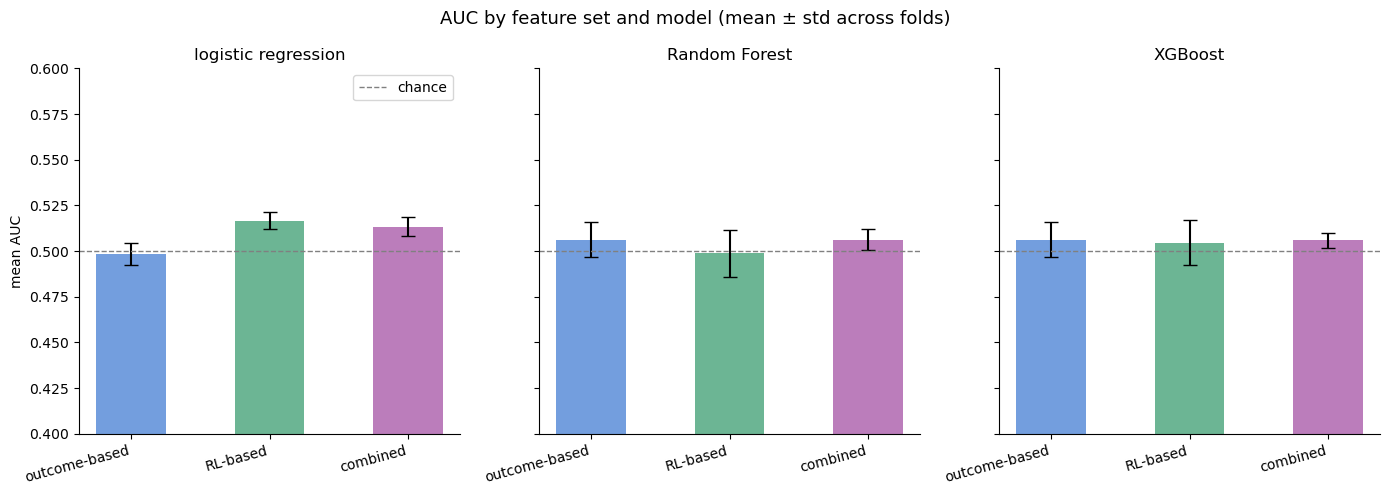

In [122]:
# plot 1: mean auc per feature set and model
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

colors = {'outcome-based': '#5B8DD9', 'RL-based': '#52A882', 'combined': '#B066B0'}
fs_names = list(feature_sets.keys())

for ax, model_name in zip(axes, models):
    means = [results[fs][model_name][0].mean() for fs in fs_names]
    stds = [results[fs][model_name][0].std() for fs in fs_names]
    bar_colors = [colors[fs] for fs in fs_names]

    ax.bar(fs_names, means, yerr=stds, capsize=5, color=bar_colors, alpha=0.85, width=0.5)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='chance')
    ax.set_title(model_name)
    ax.set_ylabel('mean AUC' if ax == axes[0] else '')
    ax.set_ylim(0.4, 0.6)
    ax.set_xticklabels(fs_names, rotation=15, ha='right')
    ax.spines[['top', 'right']].set_visible(False)

axes[0].legend()
fig.suptitle('AUC by feature set and model (mean ± std across folds)', fontsize=13)
plt.tight_layout()
plt.show()

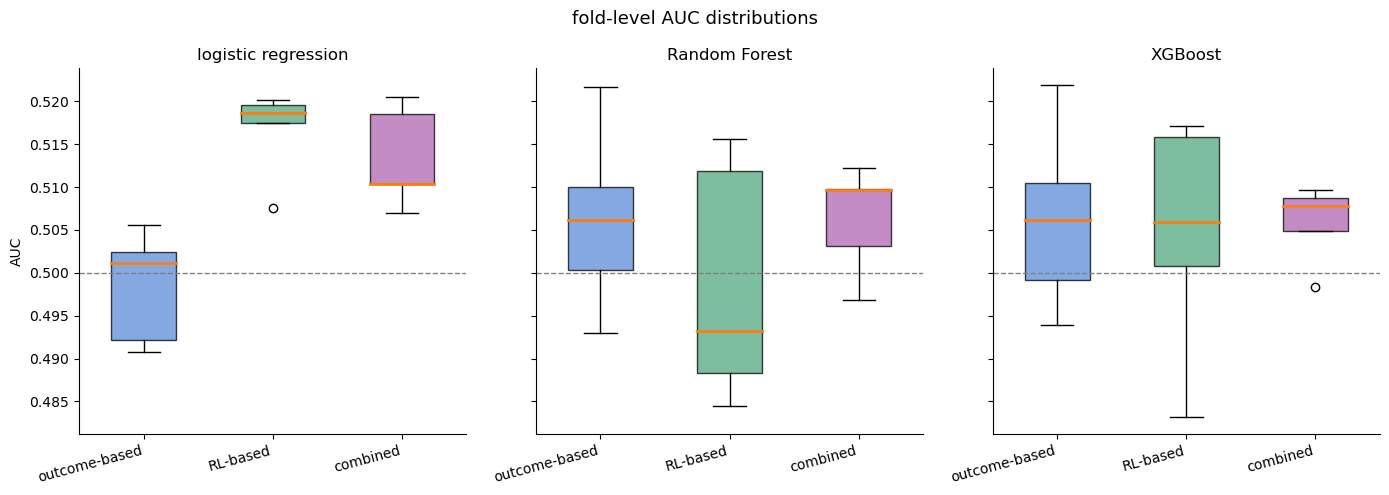

In [123]:
# plot 2: fold-level auc distributions as boxplots
fig, axes = plt.subplots(1, 3, figsize=(14, 5), sharey=True)

for ax, model_name in zip(axes, models):
    data = [results[fs][model_name][0] for fs in fs_names]
    bp = ax.boxplot(data, patch_artist=True, widths=0.5)
    for patch, fs in zip(bp['boxes'], fs_names):
        patch.set_facecolor(colors[fs])
        patch.set_alpha(0.75)
    for median in bp['medians']:
        median.set_linewidth(2)
    ax.axhline(0.5, color='gray', linestyle='--', linewidth=1)
    ax.set_title(model_name)
    ax.set_xticks([1, 2, 3])
    ax.set_xticklabels(fs_names, rotation=15, ha='right')
    ax.set_ylabel('AUC' if ax == axes[0] else '')
    ax.spines[['top', 'right']].set_visible(False)

fig.suptitle('fold-level AUC distributions', fontsize=13)
plt.tight_layout()
plt.show()

### 6. Feature importance

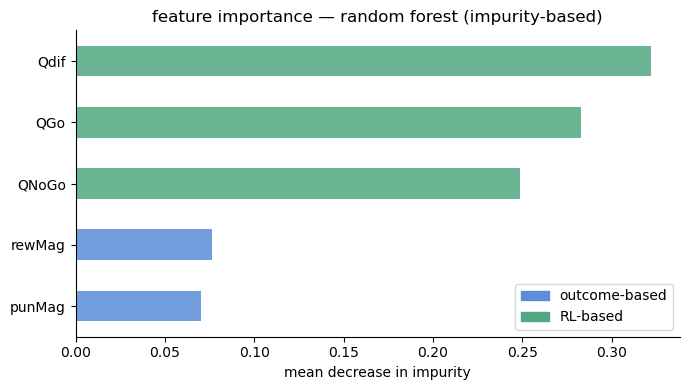

In [124]:
# training a new Random Forest on full data (unlike cv above trained on subsets) for impurity-based feature importance (using combined feature set, because all 5 features are there)
# reusing the same scaler from above since it is StandardScaler anyway and I'm fitting on the full dataset so it does not matter

outcome_features = ['rewMag', 'punMag']
rl_features = ['QGo', 'QNoGo', 'Qdif']
combined_features = outcome_features + rl_features

x_combined = df[combined_features].values
x_scaled = scaler.fit_transform(x_combined)

rf_fi = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
rf_fi.fit(x_scaled, y)

# impurity-based importance
fi = pd.Series(rf_fi.feature_importances_, index=combined_features).sort_values(ascending=True)

bar_colors = [colors['RL-based'] if f in rl_features else colors['outcome-based'] for f in fi.index]

fig, ax = plt.subplots(figsize=(7, 4))
fi.plot(kind='barh', ax=ax, color=bar_colors, alpha=0.85)
ax.set_title('feature importance — random forest (impurity-based)')
ax.set_xlabel('mean decrease in impurity')
ax.spines[['top', 'right']].set_visible(False)

legend_patches = [
    mpatches.Patch(color=colors['outcome-based'], label='outcome-based'),
    mpatches.Patch(color=colors['RL-based'], label='RL-based')
]
ax.legend(handles=legend_patches)
plt.tight_layout()
plt.show()

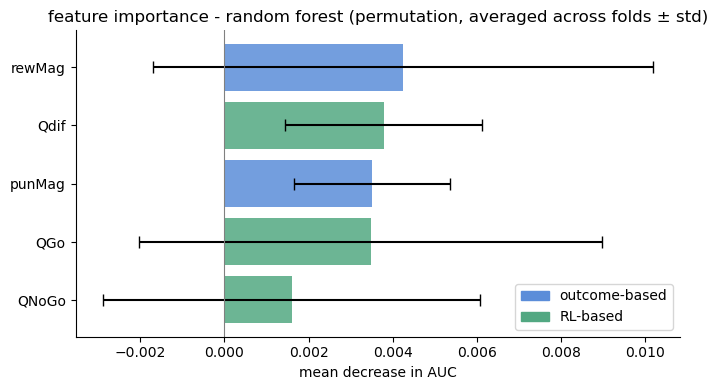

permutation importance (averaged across 5 folds):
        importance     std
rewMag      0.0042  0.0059
Qdif        0.0038  0.0023
punMag      0.0035  0.0019
QGo         0.0035  0.0055
QNoGo       0.0016  0.0045


In [125]:
# permutation importance averaged across all 5 folds (more reliable than single fold)
fold_splits = list(cv.split(x_combined, y, groups))

all_perm_importance = []
for train_idx, test_idx in fold_splits:
    x_tr = scaler.fit_transform(x_combined[train_idx])
    x_te = scaler.transform(x_combined[test_idx])
    y_tr, y_te = y[train_idx], y[test_idx]
    rf_fold = RandomForestClassifier(n_estimators=200, random_state=42, n_jobs=-1)
    rf_fold.fit(x_tr, y_tr)
    perm = permutation_importance(rf_fold, x_te, y_te, n_repeats=30, random_state=42, n_jobs=-1, scoring='roc_auc')
    all_perm_importance.append(perm.importances_mean)

perm_mean = np.mean(all_perm_importance, axis=0)
perm_std = np.std(all_perm_importance, axis=0)

fi_perm = pd.DataFrame({'importance': perm_mean,'std': perm_std}, index=combined_features).sort_values('importance', ascending=True)

bar_colors_p = [colors['RL-based'] if f in rl_features else colors['outcome-based'] for f in fi_perm.index]

fig, ax = plt.subplots(figsize=(7, 4))
ax.barh(fi_perm.index, fi_perm['importance'], xerr=fi_perm['std'], color=bar_colors_p, alpha=0.85, capsize=4)
ax.set_title('feature importance - random forest (permutation, averaged across folds ± std)')
ax.set_xlabel('mean decrease in AUC')
ax.axvline(0, color='gray', linewidth=0.8)
ax.spines[['top', 'right']].set_visible(False)
ax.legend(handles=legend_patches)
plt.tight_layout()
plt.show()

print('permutation importance (averaged across 5 folds):')
print(fi_perm.sort_values('importance', ascending=False).round(4).to_string())

### 7. Per-participant AUC (to check generalization)

mean: 0.502, std: 0.041
min: 0.388, max: 0.606
above chance: 51 out of 99


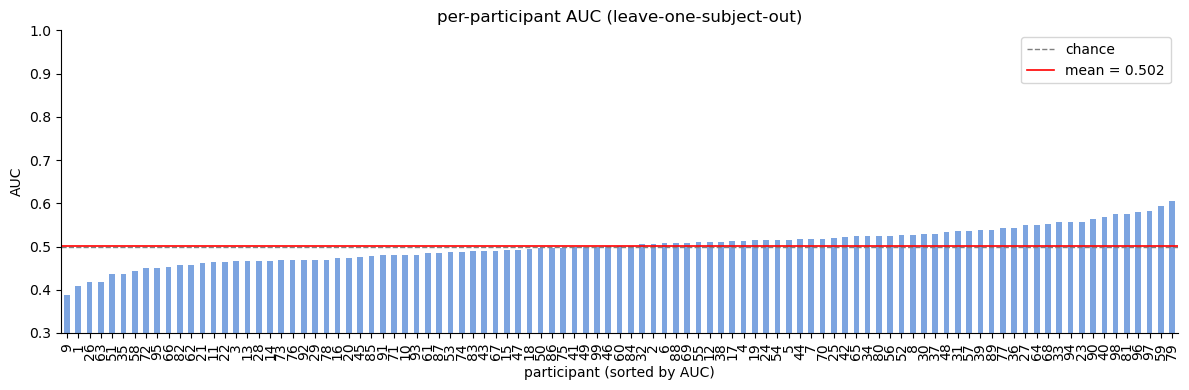

In [126]:
# for each participant: train on all others, test on them (leave-one-subject-out)
# using random forest + combined features as the main model

subject_ids = df['subject'].values
unique_subjects = np.unique(subject_ids)

per_subj_auc = {}
for subj in unique_subjects:
    test_mask = subject_ids == subj
    train_mask = ~test_mask
    x_tr = scaler.fit_transform(x_combined[train_mask])
    x_te = scaler.transform(x_combined[test_mask])
    y_tr, y_te = y[train_mask], y[test_mask]
    rf_s = RandomForestClassifier(n_estimators=100, random_state=42, n_jobs=-1)
    rf_s.fit(x_tr, y_tr)
    per_subj_auc[subj] = roc_auc_score(y_te, rf_s.predict_proba(x_te)[:, 1])

auc_series = pd.Series(per_subj_auc)
print(f'mean: {auc_series.mean():.3f}, std: {auc_series.std():.3f}')
print(f'min: {auc_series.min():.3f}, max: {auc_series.max():.3f}')
print(f'above chance: {(auc_series > 0.5).sum()} out of {len(auc_series)}')


fig, ax = plt.subplots(figsize=(12, 4))
auc_series.sort_values().plot(kind='bar', ax=ax, color='#5B8DD9', alpha=0.8)
ax.axhline(0.5, color='gray', linestyle='--', linewidth=1, label='chance')
ax.axhline(auc_series.mean(), color='red', linestyle='-', linewidth=1.2, label=f'mean = {auc_series.mean():.3f}')
ax.set_title('per-participant AUC (leave-one-subject-out)')
ax.set_xlabel('participant (sorted by AUC)')
ax.set_ylabel('AUC')
ax.set_ylim(0.3, 1.0)
ax.legend()
ax.spines[['top', 'right']].set_visible(False)
plt.tight_layout()
plt.show()

### 8. Final summary:

In [127]:
print('FINAL RESULTS SUMMARY:')
print(summary.to_string(index=False), '\n')
print(ttest_df.to_string(index=False))

FINAL RESULTS SUMMARY:
  feature set               model  mean AUC  mean accuracy
outcome-based logistic regression     0.498          0.588
outcome-based       Random Forest     0.506          0.588
outcome-based             XGBoost     0.506          0.588
     RL-based logistic regression     0.517          0.588
     RL-based       Random Forest     0.499          0.530
     RL-based             XGBoost     0.505          0.551
     combined logistic regression     0.513          0.588
     combined       Random Forest     0.506          0.538
     combined             XGBoost     0.506          0.551 

              model                comparison      t     p
logistic regression outcome-based vs RL-based -4.523 0.011
logistic regression outcome-based vs combined -5.495 0.005
logistic regression      RL-based vs combined  1.883 0.133
      Random Forest outcome-based vs RL-based  0.882 0.427
      Random Forest outcome-based vs combined -0.020 0.985
      Random Forest      RL-bas